**Importing Libraries for object tracking**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import deque
from IPython.display import HTML, display

**Visulaizing Video Properties**

In [3]:
INPUT_VIDEO = "/content/virat_test.mp4"
cap = cv2.VideoCapture(INPUT_VIDEO)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
print(f"Resolution : {width} * {height}")
print(f"FPS : {fps}")
print(f"Frames : {total_frames}")


Resolution : 1280 * 720
FPS : 25.0
Frames : 8105


**Sample frame grab and display**

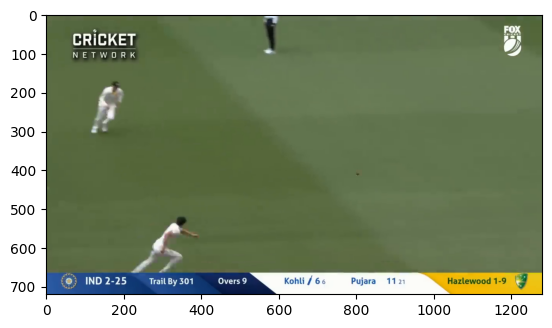

In [12]:
cap = cv2.VideoCapture(INPUT_VIDEO)
target_frame = int(total_frames * 0.065)
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, sample_frame = cap.read()
cap.release()
if not ret:
  print("not started")
else:
  img_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
  plt.imshow(img_rgb)
  plt.show()

**HSV Channel visualization**

Text(0.5, 1.0, 'value image frame')

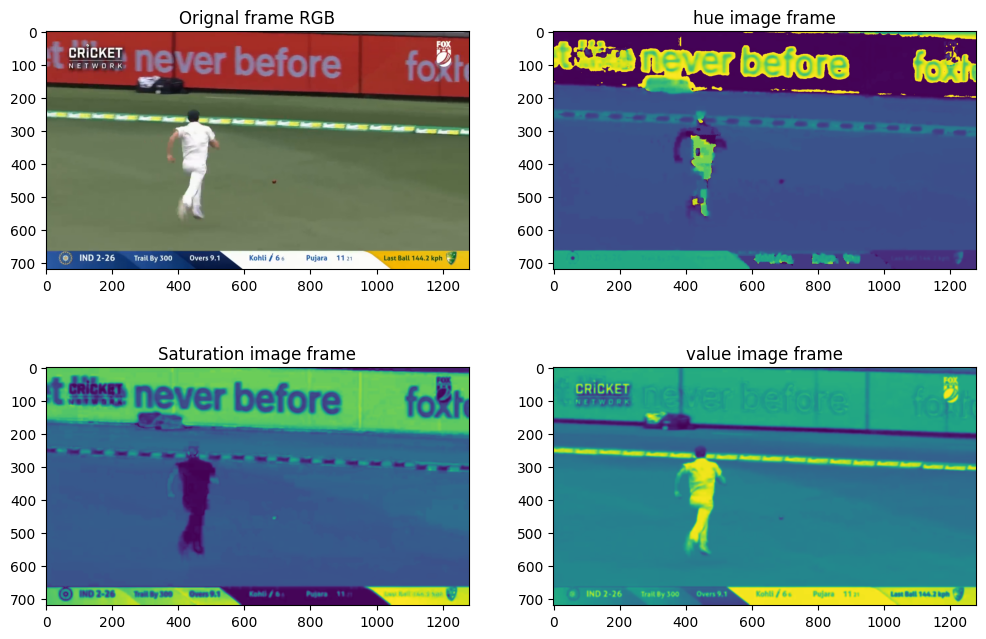

In [5]:
#Blurring the sampling frame
blurred = cv2.GaussianBlur(sample_frame, (11,11), 0)
#converting BGR frame to HSV
hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

#Frame visualization
plt.figure(figsize=(12,8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Orignal frame RGB")

plt.subplot(2, 2, 2)
plt.imshow(h)
plt.title("hue image frame")

plt.subplot(2, 2, 3)
plt.imshow(s)
plt.title("Saturation image frame")

plt.subplot(2, 2, 4)
plt.imshow(v)
plt.title("value image frame")

**HSV Value sampling at ball location**

In [8]:
print(f"HSV at ball location: {hsv[460, 680]}")

HSV at ball location: [ 40  69 118]


**Masking with lower and upper arrays**

In [13]:
# Orange-red (what the ball actually looks like at distance)
lower1 = np.array([0,  40, 60])
upper1 = np.array([25, 255, 255])

# True red (upper hue wrap)
lower2 = np.array([165, 40, 60])
upper2 = np.array([179, 255, 255])
mask1 = cv2.inRange(hsv, lower1, upper1)
mask2 = cv2.inRange(hsv, lower2, upper2)
mask  = cv2.bitwise_or(mask1, mask2)

**Erode + Dilate**

In [14]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
erode = cv2.erode(mask, kernel, iterations=2)
cleaned_mask = cv2.dilate(erode, kernel, iterations=2)

**Contour Detection + area print**

In [17]:
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
ball_contour = None
best_diff = float('inf')
for c in contours:
    a = cv2.contourArea(c)
    if 20 < a < 500:
        diff = abs(a - 100)  # closest to expected ball area
        if diff < best_diff:
            best_diff = diff
            ball_contour = c

print(f"Ball contour area: {cv2.contourArea(ball_contour)}")

Ball contour area: 108.0


**Centroid and Circle drawing**

In [18]:
sample_frame = sample_frame.copy()
if ball_contour is not None:
    m = cv2.moments(ball_contour)
    if m["m00"] != 0:
        cx = int(m['m10'] / m['m00'])
        cy = int(m["m01"] / m["m00"])
        (ex, ey), radius = cv2.minEnclosingCircle(ball_contour)
        cv2.circle(sample_frame, (int(ex), int(ey)), int(radius), (0, 0, 255), 3)
        cv2.circle(sample_frame, (cx, cy), 5, (255, 0, 0), -1)
        print(f"Ball detected at ({cx}, {cy})")

Ball detected at (305, 600)


**Video Loop**

In [19]:
INPUT_VIDEO = "/content/virat_test.mp4"
width = 1280
height = 720
fps = 25
lower1 = np.array([0,  40, 60])
upper1 = np.array([25, 255, 255])  # catches orange-red
lower2 = np.array([165, 40, 60])
upper2 = np.array([179, 255, 255])  # catches true red

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('output.avi', fourcc, fps, (width, height))

cap = cv2.VideoCapture(INPUT_VIDEO)
while True:

  ret, frame = cap.read()
  if not ret:
    break

  blurred_frame = cv2.GaussianBlur(frame, (11, 11), 0)

  hsv = cv2.cvtColor(blurred_frame, cv2.COLOR_BGR2HSV)


  mask1 = cv2.inRange(hsv, lower1, upper1)
  mask2 = cv2.inRange(hsv, lower2, upper2)
  mask  = cv2.bitwise_or(mask1, mask2)
  mask[:200, :] = 0
  cleaned_mask = mask

  contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

  ball_contour = None
  best_diff = float('inf')

  for c in contours:
      a = cv2.contourArea(c)
      if 20 < a < 500:
          diff = abs(a - 100)  # closest to expected ball area
          if diff < best_diff:
              best_diff = diff
              ball_contour = c

  sample_frame = frame.copy()
  if ball_contour is not None:
      m = cv2.moments(ball_contour)
      if m["m00"] != 0:
          cx = int(m['m10'] / m['m00'])
          cy = int(m["m01"] / m["m00"])
          (ex, ey), radius = cv2.minEnclosingCircle(ball_contour)
          cv2.circle(sample_frame, (int(ex), int(ey)), int(radius), (0, 0, 255), 3)
          cv2.circle(sample_frame, (cx, cy), 5, (255, 0, 0), -1)
          # print(f"Ball detected at ({cx}, {cy})")
  out.write(sample_frame)


cap.release()
out.release()